In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Load dataset
df = pd.read_csv(r"E:\lebika_training\weatherAUS.csv")

print(df.head())

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1007.7    

In [2]:
print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nTarget Distribution:")
print(df["RainTomorrow"].value_counts())

print("\nTarget Percentage:")
print(df["RainTomorrow"].value_counts(normalize=True) * 100)


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       895

In [3]:
print(df["RainTomorrow"].value_counts())

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64


In [4]:
features = [
    "MinTemp",
    "MaxTemp",
    "Rainfall",
    "Humidity9am",
    "Humidity3pm",
    "Pressure9am",
    "Pressure3pm",
    "Temp9am",
    "Temp3pm",
    "WindSpeed9am",
    "WindSpeed3pm",
    "Cloud9am",
    "Cloud3pm",
    "RainToday"
]

target = "RainTomorrow"

data = df[features + [target]].copy()

print(data.head())
print("\nShape:", data.shape)

   MinTemp  MaxTemp  Rainfall  Humidity9am  Humidity3pm  Pressure9am  \
0     13.4     22.9       0.6         71.0         22.0       1007.7   
1      7.4     25.1       0.0         44.0         25.0       1010.6   
2     12.9     25.7       0.0         38.0         30.0       1007.6   
3      9.2     28.0       0.0         45.0         16.0       1017.6   
4     17.5     32.3       1.0         82.0         33.0       1010.8   

   Pressure3pm  Temp9am  Temp3pm  WindSpeed9am  WindSpeed3pm  Cloud9am  \
0       1007.1     16.9     21.8          20.0          24.0       8.0   
1       1007.8     17.2     24.3           4.0          22.0       NaN   
2       1008.7     21.0     23.2          19.0          26.0       NaN   
3       1012.8     18.1     26.5          11.0           9.0       NaN   
4       1006.0     17.8     29.7           7.0          20.0       7.0   

   Cloud3pm RainToday RainTomorrow  
0       NaN        No           No  
1       NaN        No           No  
2       2.0

In [5]:
data["RainToday"] = data["RainToday"].map({
    "No": 0,
    "Yes": 1
})

In [6]:
data["RainTomorrow"] = data["RainTomorrow"].map({
    "No": 0,
    "Yes": 1
})

In [7]:
print(data.head())

print("\nMissing values:")
print(data.isnull().sum())

   MinTemp  MaxTemp  Rainfall  Humidity9am  Humidity3pm  Pressure9am  \
0     13.4     22.9       0.6         71.0         22.0       1007.7   
1      7.4     25.1       0.0         44.0         25.0       1010.6   
2     12.9     25.7       0.0         38.0         30.0       1007.6   
3      9.2     28.0       0.0         45.0         16.0       1017.6   
4     17.5     32.3       1.0         82.0         33.0       1010.8   

   Pressure3pm  Temp9am  Temp3pm  WindSpeed9am  WindSpeed3pm  Cloud9am  \
0       1007.1     16.9     21.8          20.0          24.0       8.0   
1       1007.8     17.2     24.3           4.0          22.0       NaN   
2       1008.7     21.0     23.2          19.0          26.0       NaN   
3       1012.8     18.1     26.5          11.0           9.0       NaN   
4       1006.0     17.8     29.7           7.0          20.0       7.0   

   Cloud3pm  RainToday  RainTomorrow  
0       NaN        0.0           0.0  
1       NaN        0.0           0.0  
2    

In [8]:
for column in features:
    data[column] = data[column].fillna(data[column].median())

print("\nMissing values after preprocessing:")
print(data.isnull().sum())


Missing values after preprocessing:
MinTemp            0
MaxTemp            0
Rainfall           0
Humidity9am        0
Humidity3pm        0
Pressure9am        0
Pressure3pm        0
Temp9am            0
Temp3pm            0
WindSpeed9am       0
WindSpeed3pm       0
Cloud9am           0
Cloud3pm           0
RainToday          0
RainTomorrow    3267
dtype: int64


In [9]:
data = data.dropna(subset=["RainTomorrow"])

print("\nFinal shape:", data.shape)


Final shape: (142193, 15)


In [10]:
X = data[features].values
y = data[target].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (142193, 14)
y shape: (142193,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (113754, 14)
Testing data: (28439, 14)


In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
scaler.fit_transform(X_train)
scaler.transform(X_test)

array([[ 0.45805943,  1.36143631, -0.27481985, ...,  1.02472769,
         0.14046181, -0.53256917],
       [-0.59013789, -0.98670808, -0.27481985, ...,  1.02472769,
         1.08379002, -0.53256917],
       [ 0.75530941,  0.20845523, -0.27481985, ...,  1.02472769,
        -0.80286639, -0.53256917],
       ...,
       [-0.71529578, -0.70549318, -0.27481985, ...,  0.15357092,
         0.14046181, -0.53256917],
       [ 1.58448043,  0.92555322, 11.71833737, ...,  0.58914931,
         1.08379002,  1.87769036],
       [ 0.30161207,  0.25063747, -0.27481985, ...,  0.15357092,
         0.14046181, -0.53256917]], shape=(28439, 14))

In [14]:
X_train_bias = np.c_[
    np.ones(X_train.shape[0]),
    X_train
]

X_test_bias = np.c_[
    np.ones(X_test.shape[0]),
    X_test
]

print(X_train_bias.shape)
print(X_test_bias.shape)

(113754, 15)
(28439, 15)


In [15]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [16]:
print(sigmoid(-5))
print(sigmoid(0))
print(sigmoid(5))

0.0066928509242848554
0.5
0.9933071490757153


In [17]:
weights = np.zeros(X_train_bias.shape[1])

print("Number of weights:", len(weights))

Number of weights: 15


In [18]:
learning_rate = 0.01
epochs = 1000

n = X_train_bias.shape[0]

loss_history = []

for epoch in range(epochs):

    # 1. Linear equation
    z = np.dot(X_train_bias, weights)

    # 2. Sigmoid
    predictions = sigmoid(z)

    # 3. Log loss
    loss = -np.mean(
        y_train * np.log(predictions + 1e-9)
        +
        (1 - y_train) * np.log(1 - predictions + 1e-9)
    )

    loss_history.append(loss)

    # 4. Gradient
    gradient = np.dot(
        X_train_bias.T,
        (predictions - y_train)
    ) / n

    # 5. Update weights
    weights = weights - learning_rate * gradient

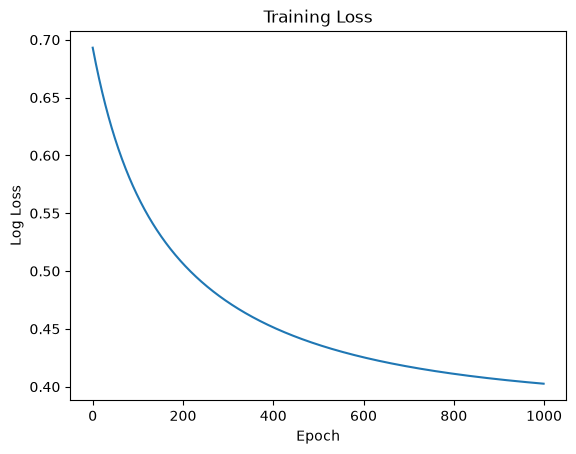

In [19]:
plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Training Loss")

plt.show()

In [20]:
z_test = np.dot(X_test_bias, weights)

probabilities = sigmoid(z_test)

print(probabilities[:10])

[0.14741773 0.50988895 0.34946974 0.09640647 0.10732411 0.04418627
 0.19289285 0.10424582 0.02083995 0.05840941]


In [21]:
y_pred = (probabilities >= 0.5).astype(int)

print(y_pred[:20])

[0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]


In [22]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.833221983895355
